# [문제] bmi.csv 데이터 파일을 사용하여 아래 문제를 구현하는 코드를 작성하시오.

## 제출 파일명: 홍길동_0504.ipynb (구글드라이브와 클래스룸 두곳에 모두 업로드 할것!!)

### <공통 처리 조건>
- 상위 데이터 100개중 height와 weight를 사용해서 클러스터링 데이터로 사용할것
- K-means clustering으로 구현한 다음  AgglomerativeClustering으로 구현하는 코드를 작성 할 것.

### (1) K-means clustering으로 구현하는 코드를 작성하시오.
### (2) AgglomerativeClustering으로 구현하는 코드를 작성하시오.

## 파일 로드

In [1]:
import pandas as pd

df = pd.read_csv("bmi.csv", encoding='utf-8')
df.head(3)

,height,weight,label
0,142,62,fat
1,142,73,fat
2,177,61,normal


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   height  20000 non-null  int64
 1   weight  20000 non-null  int64
 2   label   20000 non-null  str  
dtypes: int64(2), str(1)
memory usage: 468.9 KB


## 전처리

In [3]:
df_bmi = df.iloc[:100,:2]

In [4]:
df_bmi.tail(3)

,height,weight
97,180,75
98,191,60
99,126,55


## 산점도 그래프 그려보기

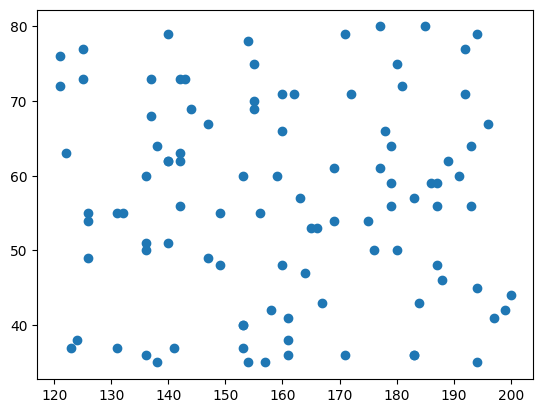

In [5]:
import matplotlib.pyplot as plt

features = pd.DataFrame(df_bmi, columns=['height', 'weight'])
plt.scatter(features.values[:,0], features.values[:,1])
plt.show()

## K-means clustering 결과

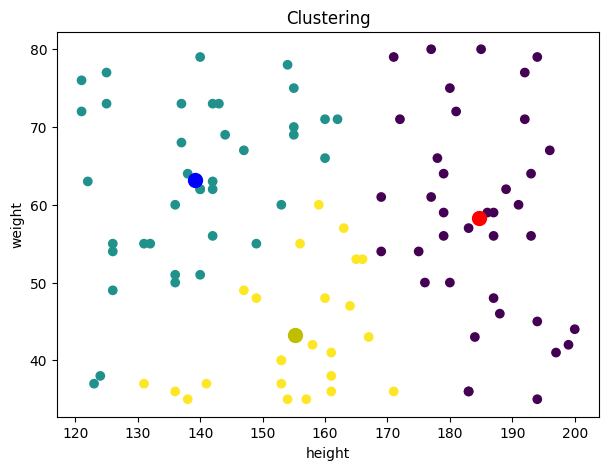

In [8]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, random_state=1)
km.fit(df_bmi)
y_pred = km.predict(df_bmi)
c0, c1, c2 = km.cluster_centers_


plt.figure(figsize=(7,5))
plt.scatter(df_bmi.iloc[:,0], df_bmi.iloc[:,1], c=y_pred)
plt.scatter(c0[0], c0[1], s=100, c='r')
plt.scatter(c1[0], c1[1], s=100, c='b')
plt.scatter(c2[0], c2[1], s=100, c='y')
plt.title('Clustering')
plt.xlabel('height')
plt.ylabel('weight')
plt.show()

## AgglomerativeClustering 결과

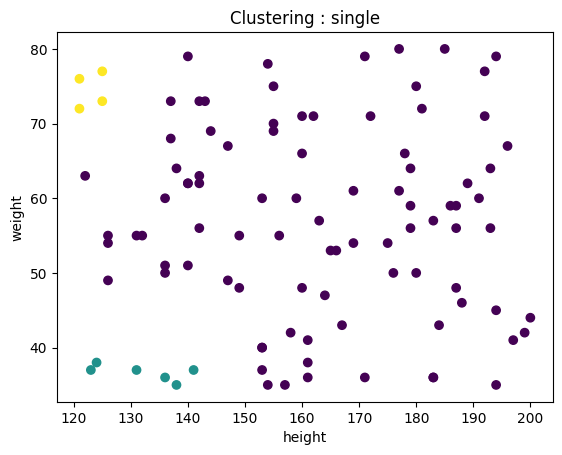

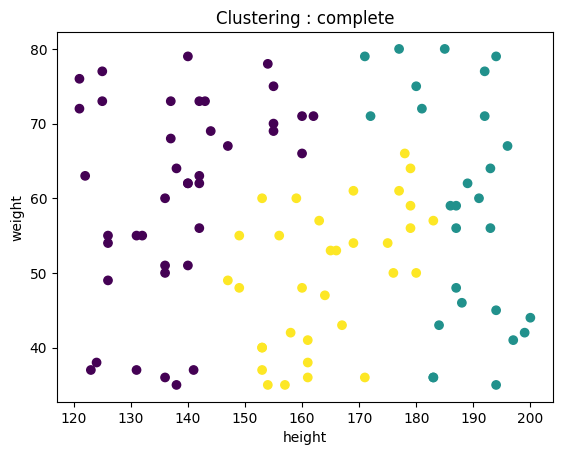

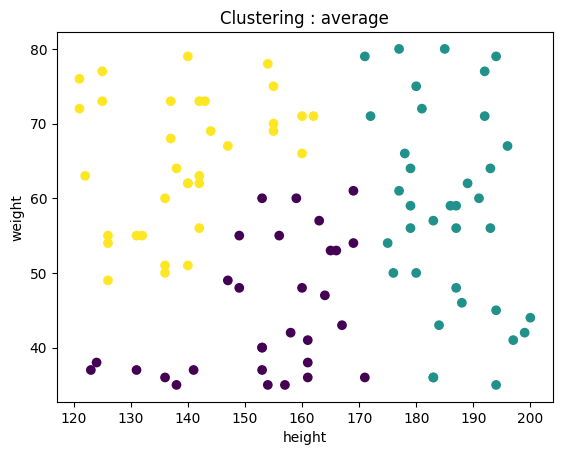

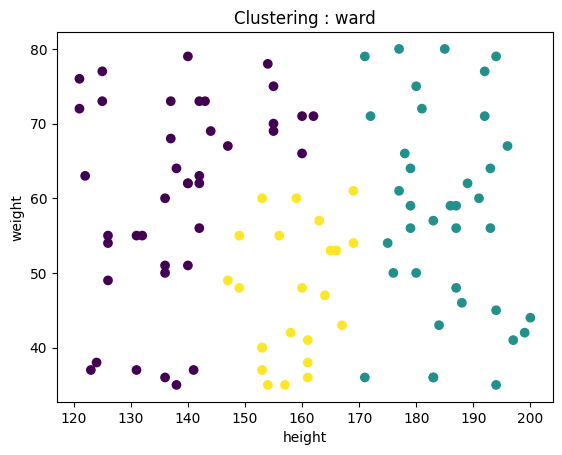

In [13]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

linkage = ['single','complete', 'average', 'ward']
for idx, i in enumerate(linkage):
    plt.figure(idx)
    hier = AgglomerativeClustering(n_clusters=3, metric = 'euclidean', linkage=i)
    hier.fit(df_bmi)
    plt.scatter(df_bmi.iloc[:,0], df_bmi.iloc[:,1], c= hier.labels_)
    plt.title('Clustering : ' + i)
    plt.xlabel('height')
    plt.ylabel('weight')
plt.show()